<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 6. Redes Avanzadas</font></h1>

<h1><font color="#113D68" size=4>1. Data Augmentation</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Data Augmentation](#section1)
* [2. Redimensionar imagen](#section2)
* [3. Convertir la imagen a escala de grises](#section3)
* [4. Rotar la imagen](#section4)
* [5. Recorte aleatorio](#section5)
* [6. Desenfoque gausiano](#section6)
* [7. Ruido gaussiano](#section7)
* [8. Inversión aleatoria](#section8)
* [9. Script para aumento de datos](#section9)
* [10. Consejos finales](#section10)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

La preparación de datos es necesaria cuando se trabaja con redes neuronales y modelos de Deep Learning. También se requiere cada vez más el aumento de datos en tareas de reconocimiento de objetos más complejas. En esta lección, descubrirá cómo utilizar la preparación y el aumento de datos con sus conjuntos de datos de imágenes al desarrollar y evaluar modelos de Deep Learning. Después de completar esta lección, sabrá:
* Acerca de la API de aumento de imágenes proporcionada por Keras y cómo usarla con sus modelos.
* Cómo realizar diferentes transformaciones de aumento de datos
* Cómo guardar las imágenes generadas.

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Data Augmentation</font>

La mayoría de los modelos necesitan una cantidad considerable de datos para ser entrenados, probados y validados. Sin embargo, estos datos no siempre están disponibles en la cantidad o formato adecuados para el modelo que has creado. La ampliación de datos (_data augmentation_) es una excelente manera de maximizar el uso de los datos que ya tienes disponibles.

Por ejmplo, en el problema MINST, en lugar de dibujar manualmente todas las posibles variaciones de un carácter en el sistema de escritura, basta con dibujar unas pocas y luego aplicar técnicas de _data augmentation_. De esta manera, podemos generar una variedad de imágenes a partir de una sola imagen original.

PyTorch ofrece un módulo llamado `torchvision.transforms`, que nos permite ampliar imágenes de diferentes maneras. Esto nos permite generar múltiples imágenes a partir de una sola, lo que a su vez nos ayuda a crear un conjunto de datos más denso. Primero, repasaremos algunas transformaciones básicas utilizando `torchvision.transforms` y, al final, presentaremos un script que te permitirá recorrer carpetas jerárquicas de imágenes, aplicarles data augmentation y almacenarlas manteniendo la misma estructura de carpetas. El módulo `torchvision.transforms` facilita enormemente este proceso, permitiendo realizar estas transformaciones de manera fluida y sencilla.

También podríamos realizar estas operaciones utilizando la biblioteca **OpenCV**, pero en este ejemplo no la usaremos.


<img src="Img/data-augmentation.jpeg" width="550" height="400" />

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Puede obtener más información sobre la API del generador de datos de imágenes de Torchvision ver la [documentación](https://pytorch.org/vision/0.9/transforms.html)


<a id="section11"></a>
# <font color="#004D7F" size=5>1.1. Librerías necesarias</font>

Lo primero es tener todas las librerías necesarias instaladas. 

In [1]:
# En Colab: sube Datos.zip (panel Archivos) y se descomprime aquí
import os, zipfile
if os.path.exists('Datos.zip') and not os.path.exists('Data'):
    zipfile.ZipFile('Datos.zip').extractall('.')

In [2]:
import PIL
import torch 
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sys
import torchvision.transforms as T

> **Actualización:** torchvision recomienda hoy `torchvision.transforms.v2` (misma API y además soporta cajas y máscaras). En estos ejemplos basta con cambiar el import por `import torchvision.transforms.v2 as T`.

Obviamente, necesitamos una imagen con la que trabajar, de lo contrario, todo el artículo sería redundante. 

Abramos la imagen utilizando la biblioteca $\texttt{PIL.Image}$ y almacenémosla en una variable llamada $\texttt{orig\_img}$

In [3]:
orig_img = Image.open(Path('Data') / 'cat.png').convert('RGB')  # convert('RGB') evita problemas con PNG RGBA

Ahora, visualicemos la imagen con la que vamos a trabajar utilizando la biblioteca $\texttt{matplotlib.pyplot}$:

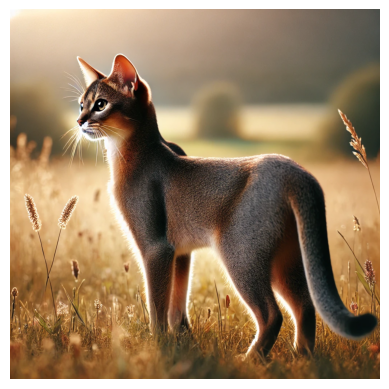

In [4]:
plt.imshow(orig_img)
plt.axis('off')
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Redimensionar imagen</font>

A veces, las imágenes son demasiado grandes para procesarlas, por lo que es necesario redimensionarlas para que nuestros modelos puedan entrenarse de manera eficiente. Es importante tener en cuenta que este proceso debe aplicarse a todas las imágenes, incluso después de la ampliación de datos (_data augmentation_), ya que las redes neuronales convolucionales (CNNs) solo pueden entrenarse con imágenes de tamaño uniforme.

Podemos redimensionar la imagen utilizando `torchvision.transforms.Resize`:

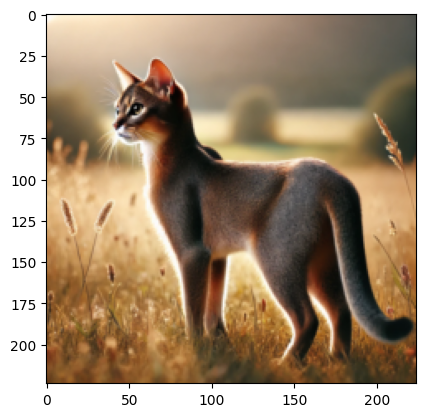

In [5]:
resize_transform = T.Resize(size=(224, 224))
resized_image = resize_transform(orig_img)
plt.imshow(resized_image)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Convertir la imagen a escala de grises</font>

Convertir una imagen a su representación en escala de grises es una técnica comúnmente utilizada para extraer descriptores de la imagen. Procesar imágenes en escala de grises es menos costoso computacionalmente que trabajar con imágenes en color, ya que reduce la cantidad de información procesada sin perder características esenciales para muchas tareas de visión por computadora.

En PyTorch, podemos realizar esta conversión con `torchvision.transforms.Grayscale`:

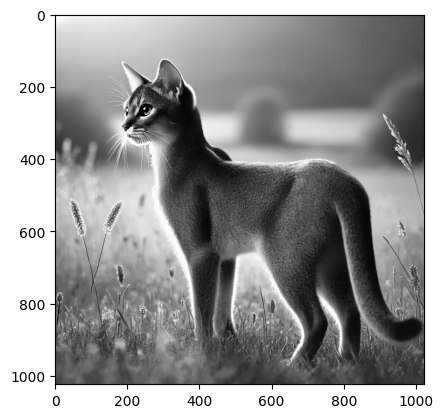

In [6]:
grayscale_transform = T.Grayscale(num_output_channels=3)  # 3 canales: mantiene la forma que espera una CNN RGB 
grayscaled_image = grayscale_transform(orig_img)  
plt.imshow(grayscaled_image)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Rotar la imagen</font>

La rotación de imágenes es una técnica común en el procesamiento de imágenes. Permite que el modelo extraiga y compare características desde diferentes perspectivas, ayudando a mejorar la generalización del modelo. Además, es una excelente manera de aumentar el tamaño del conjunto de entrenamiento al generar múltiples versiones de la misma imagen con diferentes orientaciones.

En este caso, realizaremos tres rotaciones en ángulos de 45°, 65° y 85°, pero puedes configurarlo de manera aleatoria o elegir tus propios ángulos de rotación.

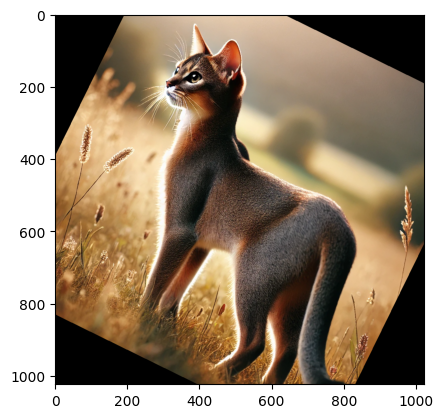

In [7]:
random_rotation_transformation_45 = T.RandomRotation(45)  # ángulo aleatorio en [-45, 45]  
random_rotation_transformation_85 = T.RandomRotation(85)  
random_rotation_transformation_120 = T.RandomRotation(120)

plt.imshow(random_rotation_transformation_45(orig_img))

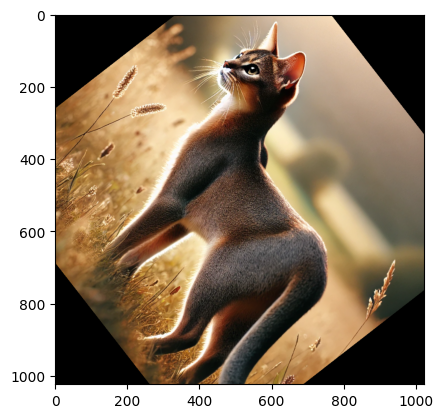

In [8]:
plt.imshow(random_rotation_transformation_85(orig_img))

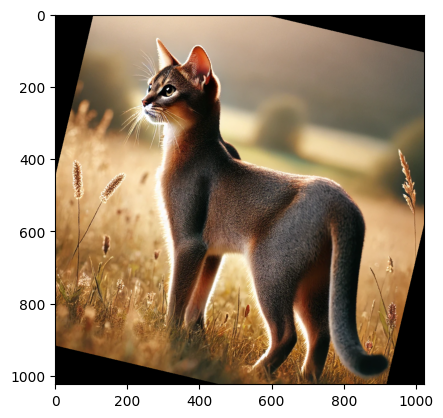

In [9]:
plt.imshow(random_rotation_transformation_120(orig_img))

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Recorte aleatorio </font>

En situaciones del mundo real, los objetos no siempre son completamente visibles en una imagen ni aparecen en la misma escala que en los datos de entrenamiento. Por esta razón, cuando entrenamos nuestro modelo, es útil añadir variedad al conjunto de datos recortando partes de las imágenes.

Este proceso permite que el modelo aprenda a hacer predicciones precisas incluso cuando el objeto no está completamente visible en la imagen. Así, generamos nuevas imágenes a partir de secciones recortadas de la imagen original.

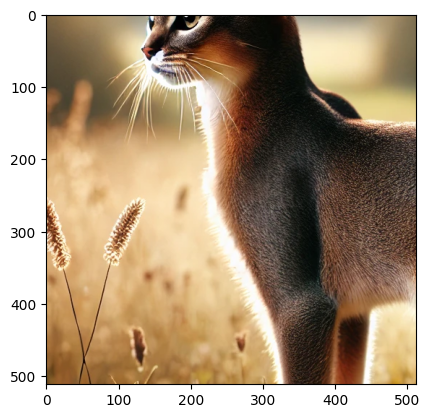

In [10]:
size_of_crop = (orig_img.size[1] // 2, orig_img.size[0] // 2)  # (alto, ancho): la mitad de la imagen 
random_crops = T.RandomCrop(size=size_of_crop)
required_image = random_crops(orig_img)  

plt.imshow(required_image)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section6"></a>
# <font color="#004D7F" size=6>6. Desenfoque gausiano </font>

El desenfoque gaussiano se utiliza para eliminar el ruido y las impurezas de una imagen. Se aplica suavizando la imagen mediante una función gaussiana, lo que ayuda a eliminar componentes de alta frecuencia que pueden generar características falsas durante el entrenamiento del modelo.

Podemos controlar el nivel de suavizado ajustando el valor de sigma, que determina la intensidad del desenfoque al pasar el parámetro a la función.

In [11]:
gausian_blur_transformation_13 = T.GaussianBlur(kernel_size=(7, 13), sigma=(6, 9))
gausian_blur_transformation_56 = T.GaussianBlur(kernel_size=(7, 13), sigma=(5, 8))
gausian_blurred_image_13 = gausian_blur_transformation_13(orig_img)
gausian_blurred_image_56 = gausian_blur_transformation_56(orig_img)

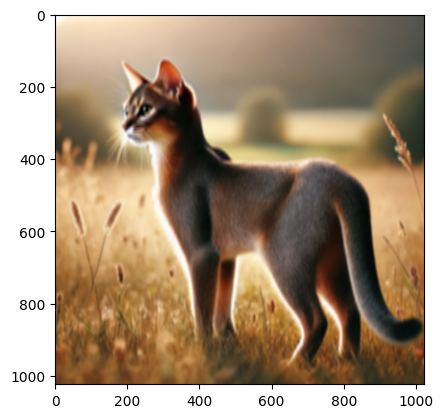

In [12]:
plt.imshow(gausian_blurred_image_13)

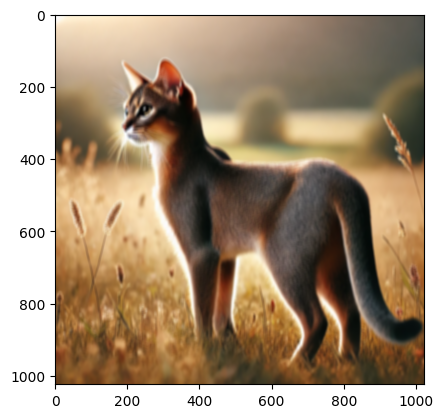

In [13]:
plt.imshow(gausian_blurred_image_56)

La ejecución de este ejemplo crea versiones cambiadas de los dígitos. Nuevamente, esto no es necesario para MNIST ya que los dígitos escritos a mano ya están centrados, pero puede ver cómo esto podría ser útil en dominios de problemas más complejos.

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section7"></a>
# <font color="#004D7F" size=6>7. Ruido gaussiano </font>

Añadir ruido gaussiano a una imagen ayuda a generar variaciones estratégicas en los datos de entrenamiento, lo que puede mejorar la robustez del modelo al hacerlo menos sensible a pequeñas alteraciones en las imágenes de entrada.

La función de ruido gaussiano en `torchvision.transforms` genera ruido con una distribución gaussiana, pero solo funciona con tensores. Por lo tanto, debemos crear una pequeña función envolvente (wrapper) para convertir la imagen a un tensor y luego volver a imagen.

Podemos ajustar la intensidad del ruido modificando el parámetro de ruido pasado a la función.

In [14]:
colour_jitter_transformation_1 = T.ColorJitter(brightness=(0.5, 1.5), contrast=(3), saturation=(0.3, 1.5), hue=(-0.1, 0.1))
colour_jitter_transformation_2 = T.ColorJitter(brightness=(0.7), contrast=(6), saturation=(0.9), hue=(-0.1, 0.1))
colour_jitter_transformation_3 = T.ColorJitter(brightness=(0.5, 1.5), contrast=(2), saturation=(1.4), hue=(-0.1, 0.5))

colour_jitter_image_1 = colour_jitter_transformation_1(orig_img)
colour_jitter_image_2 = colour_jitter_transformation_2(orig_img)
colour_jitter_image_3 = colour_jitter_transformation_3(orig_img)

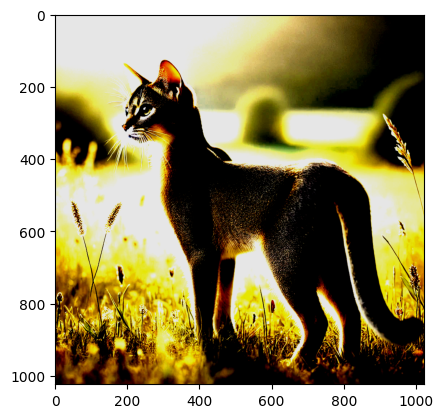

In [15]:
plt.imshow(colour_jitter_image_1)

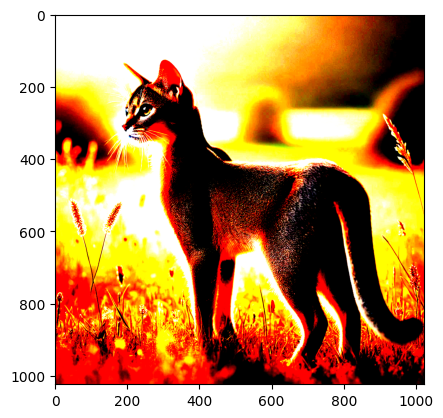

In [16]:
plt.imshow(colour_jitter_image_2)

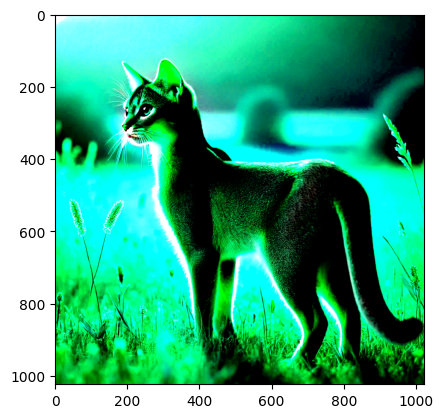

In [17]:
plt.imshow(colour_jitter_image_3)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section8"></a>
# <font color="#004D7F" size=6>8. Inversión aleatoria </font>

La función `RandomInvert` invierte los colores de una imagen de manera aleatoria con una determinada probabilidad. Esta técnica ayuda a aumentar la diversidad del conjunto de datos, permitiendo que el modelo aprenda a reconocer características en diferentes representaciones de la misma imagen.

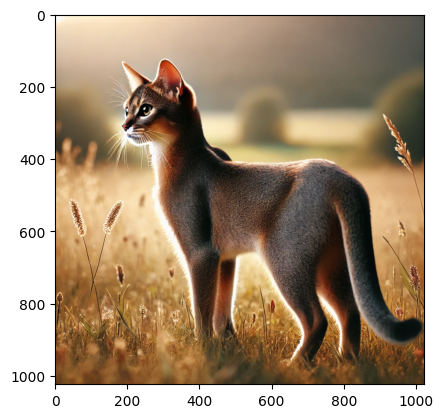

In [18]:
plt.imshow(orig_img)

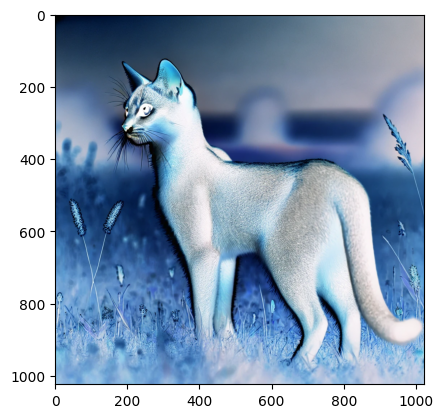

In [19]:
transform = T.RandomInvert(p=1.0)  # p=1 para verlo siempre; en entrenamiento se usa p<1 (por defecto 0.5) 
inverted_img = transform(orig_img)
plt.imshow(inverted_img)

<a id="section9"></a>
# <font color="#004D7F" size=6>9. Script para aumento de datos </font>

Ya hemos visto todas estas transformaciones de forma individual, pero no tendría sentido aplicarlas una por una manualmente a cada imagen. A menos que disfrutes del sufrimiento, no vale la pena hacerlo así.

El siguiente script recorre los archivos con las imágenes de entrenamiento, genera todas las ampliaciones de datos (augmentations) y luego las almacena en otra carpeta, manteniendo la misma estructura de archivos.

Pasos previos antes de ejecutar el script:
1. Asegúrate de tener una carpeta que contenga subcarpetas con las imágenes de entrenamiento, donde cada subcarpeta lleva el nombre de la etiqueta de la clase correspondiente.
2. Crea una nueva carpeta vacía para almacenar las imágenes aumentadas.
3. Especifica la ruta de la carpeta con las imágenes a ampliar en la variable master_dataset.
4. Define la ruta de la carpeta donde se guardarán las imágenes aumentadas en la variable augmented_dataset.
5. Ejecuta el script, y… Et voilà, todas las imágenes aumentadas estarán en la nueva carpeta.

Antes de ejecutar el script, la carpeta especificada para las imágenes aumentadas debe estar vacía.

In [20]:
# This script aims to create augmented images from one image to create a larger dataset for our cnn model
# The augmentation this script will perform on each object is 
# orig_img,grayscaled_image,random_rotation_transformation_45_image,random_rotation_transformation_65_image,random_rotation_transformation_85_image,gausian_blurred_image_13_image,gausian_blurred_image_56_image,gausian_image_3,gausian_image_6,gausian_image_9,colour_jitter_image_1,colour_jitter_image_2,colour_jitter_image_3

#call the function creating file with augmented image give path of dataset and path of folder where you want the augmented images to be stored
import PIL
import torch 
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sys
import torchvision.transforms as T
import os

#torch.transforms

#grayscale
grayscale_transform = T.Grayscale(3)

#random rotation
random_rotation_transformation_45 = T.RandomRotation(45)
random_rotation_transformation_85 = T.RandomRotation(85)
random_rotation_transformation_65 = T.RandomRotation(65)

#Gausian Blur
gausian_blur_transformation_13 = T.GaussianBlur(kernel_size = (7,13), sigma = (6 , 9))
gausian_blur_transformation_56 = T.GaussianBlur(kernel_size = (7,13), sigma = (5 , 8))

#Gausian Noise
def addnoise(input_image, noise_factor = 0.3):
    inputs = T.ToTensor()(input_image)
    noisy = inputs + torch.rand_like(inputs) * noise_factor
    noisy = torch.clip (noisy,0,1.)
    output_image = T.ToPILImage()
    image = output_image(noisy)
    return image

#Colour Jitter
colour_jitter_transformation_1 = T.ColorJitter(brightness=(0.5,1.5),contrast=(3),saturation=(0.3,1.5),hue=(-0.1,0.1))
colour_jitter_transformation_2 = T.ColorJitter(brightness=(0.7),contrast=(6),saturation=(0.9),hue=(-0.1,0.1))
colour_jitter_transformation_3 = T.ColorJitter(brightness=(0.5,1.5),contrast=(2),saturation=(1.4),hue=(-0.1,0.5))

#Random invert
random_invert_transform = T.RandomInvert()

def augment_image(img_path):
    #orig_image
    orig_img = Image.open(Path(img_path))
    #grayscale
    grayscaled_image=grayscale_transform(orig_img)
    #grayscaled_image.show()
    #random rotation
    random_rotation_transformation_45_image=random_rotation_transformation_45(orig_img)
    #random_rotation_transformation_45_image.show()
    random_rotation_transformation_85_image=random_rotation_transformation_85(orig_img)
    #random_rotation_transformation_85_image.show()
    random_rotation_transformation_65_image=random_rotation_transformation_65(orig_img)
    #random_rotation_transformation_65_image.show()
    #Gausian Blur
    gausian_blurred_image_13_image = gausian_blur_transformation_13(orig_img)
    #gausian_blurred_image_13_image.show()
    gausian_blurred_image_56_image = gausian_blur_transformation_56(orig_img)
    #gausian_blurred_image_56_image.show()
    #Gausian Noise
    gausian_image_3 = addnoise(orig_img)
    #gausian_image_3.show()
    gausian_image_6 = addnoise(orig_img,0.6)
    #gausian_image_6.show()
    gausian_image_9 = addnoise(orig_img,0.9)
    #gausian_image_9.show()
    #Color Jitter
    colour_jitter_image_1 = colour_jitter_transformation_1(orig_img)
    #colour_jitter_image_1.show()
    colour_jitter_image_2 = colour_jitter_transformation_2(orig_img)
    #colour_jitter_image_2.show()
    colour_jitter_image_3 = colour_jitter_transformation_3(orig_img)
    #colour_jitter_image_3.show()
    return [orig_img,grayscaled_image,random_rotation_transformation_45_image,random_rotation_transformation_65_image,random_rotation_transformation_85_image,gausian_blurred_image_13_image,gausian_blurred_image_56_image,gausian_image_3,gausian_image_6,gausian_image_9,colour_jitter_image_1,colour_jitter_image_2,colour_jitter_image_3]

Probando augment_image con: Data/cat.png


Se generaron 13 imágenes


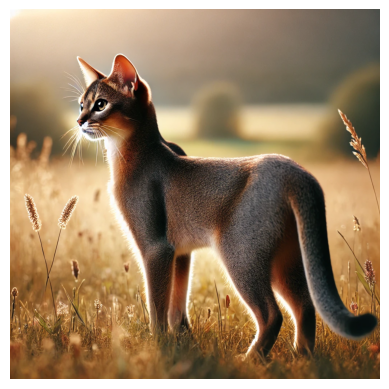

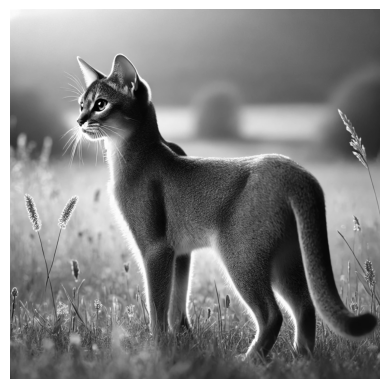

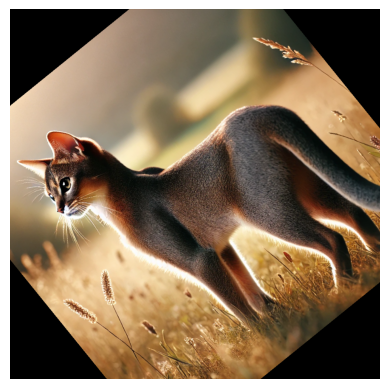

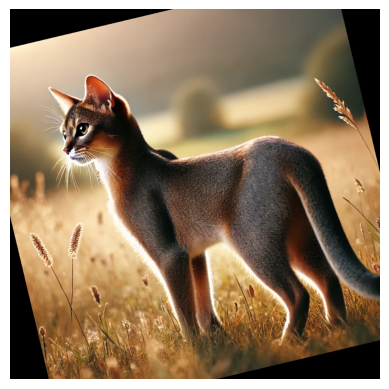

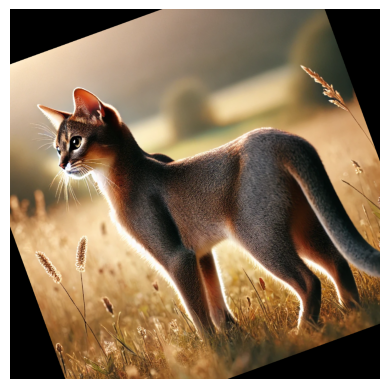

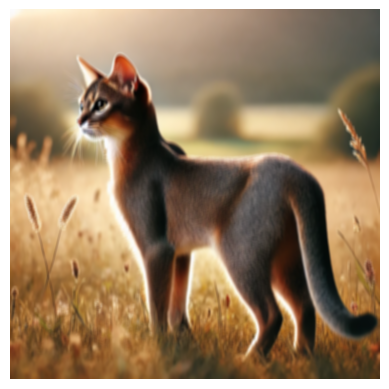

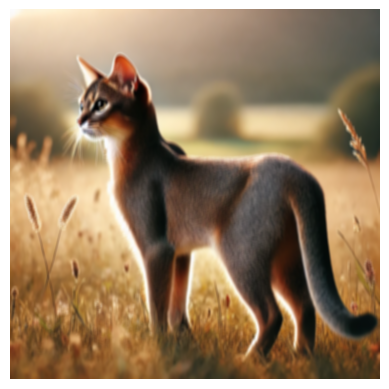

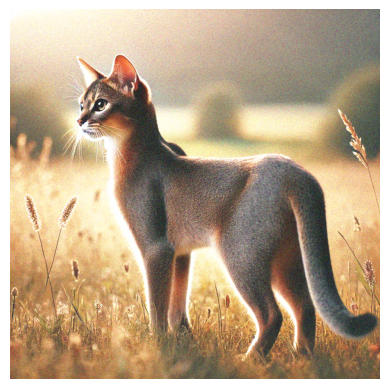

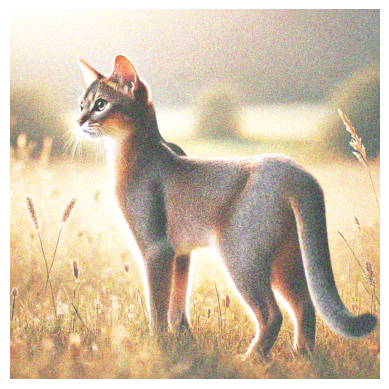

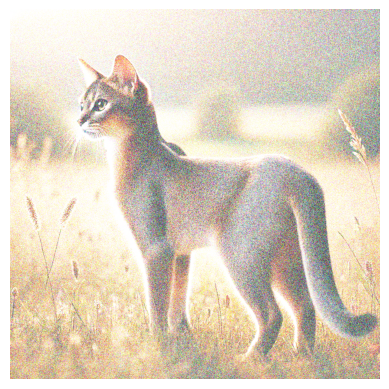

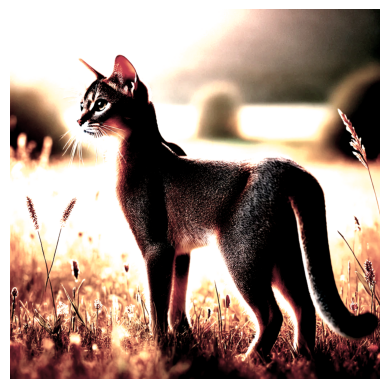

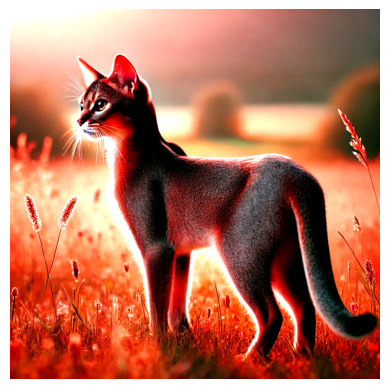

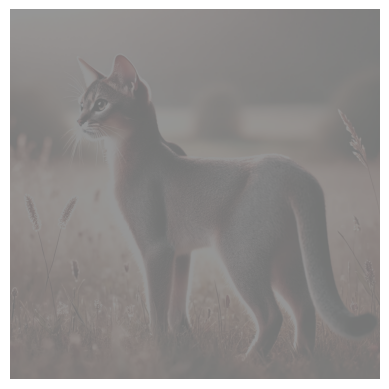

In [21]:
test_image_path = "Data/cat.png"  # Cambia esto a una imagen existente en tu dataset
if os.path.exists(test_image_path):
    print(f"Probando augment_image con: {test_image_path}")
    images = augment_image(test_image_path)
    print(f"Se generaron {len(images)} imágenes")

    for img in images:
        plt.figure()
        plt.imshow(img)
        plt.axis("off")
        plt.show()
else:
    print(f"Imagen de prueba no encontrada: {test_image_path}")

In [22]:
def creating_file_with_augmented_images(file_path_master_dataset, file_path_augmented_images):
    master_dataset_folder = file_path_master_dataset
    files_in_master_dataset = os.listdir(file_path_master_dataset)
    augmented_images_folder = file_path_augmented_images

    # Asegurar que la carpeta destino exista
    if not os.path.exists(augmented_images_folder):
        os.makedirs(augmented_images_folder)
        print(f"Carpeta creada: {augmented_images_folder}")

    counter = 0
    
    for element in files_in_master_dataset:
        full_element_path = os.path.join(master_dataset_folder, element)

        # Verificar si es una carpeta
        if not os.path.isdir(full_element_path):
            print(f"Ignorado (no es carpeta): {full_element_path}")
            continue  # Si es un archivo, lo ignoramos

        # Crear carpeta para la categoría en la salida
        element_folder = os.path.join(augmented_images_folder, element)
        if not os.path.exists(element_folder):
            os.makedirs(element_folder)
            print(f"Subcarpeta creada: {element_folder}")

        images_in_folder = os.listdir(full_element_path)
        
        counter += 1
        counter2 = 0
        for image in images_in_folder:
            image_path = os.path.join(full_element_path, image)

            # Verificar si el archivo es una imagen válida (ignoramos otros archivos)
            if not image.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                print(f"Ignorado (no es una imagen válida): {image_path}")
                continue

            print(f"Procesando imagen: {image_path}")

            # Verificar si la imagen realmente existe
            if not os.path.exists(image_path):
                print(f"Error: Imagen no encontrada: {image_path}")
                continue

            required_images = augment_image(image_path)

            # Asegurar que la función de aumento devuelve imágenes
            if not required_images or len(required_images) == 0:
                print(f"Error: augment_image() no generó imágenes para {image_path}")
                continue

            print(f"Se generaron {len(required_images)} imágenes aumentadas para {image}")

            counter2 += 1
            counter3 = 0
            for augmented_image in required_images:
                counter3 += 1
                output_path = os.path.join(element_folder, f"{counter}_{counter2}_{counter3}.png")
                print(f"Guardando imagen en: {output_path}")
                augmented_image.save(output_path)
                
#augmented dataset path - Recordad que debe exisir la ca
augmented_dataset = "Datasets/augmented_images_dataset"

# master dataset path
master_dataset = "Data/images"

# run the program
creating_file_with_augmented_images(master_dataset,augmented_dataset)

Carpeta creada: Datasets/augmented_images_dataset
Subcarpeta creada: Datasets/augmented_images_dataset/Clase2
Procesando imagen: Data/images/Clase2/image_00255.jpg


Se generaron 13 imágenes aumentadas para image_00255.jpg
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_1.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_2.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_3.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_4.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_5.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_6.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_7.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_8.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_9.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase2/1_1_10.png


...

Se generaron 13 imágenes aumentadas para image_00017.jpg
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_1.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_2.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_3.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_4.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_5.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_6.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_7.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_8.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_9.png


Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_10.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_11.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_12.png
Guardando imagen en: Datasets/augmented_images_dataset/Clase1/2_30_13.png


Ignorado (no es carpeta): Data/images/.DS_Store


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section10"></a>
# <font color="#004D7F" size=6>10. Consejos finales </font>

Los datos de imagen son únicos en el sentido de que puede revisar las copias transformadas de los datos y obtener rápidamente una idea de cómo su modelo puede percibir las entradas. A continuación, se incluyen algunos consejos para aprovechar al máximo la preparación y el aumento de datos de imágenes:
* **Revisar el conjunto de datos**. Tómese un tiempo para revisar su conjunto de datos con gran detalle. Mira las imágenes. Tome nota de la preparación de imágenes y los aumentos que podrían beneficiar el proceso de entrenamiento de su modelo, como la necesidad de manejar diferentes cambios, rotaciones o volteretas de objetos en la escena.
* **Revisar ampliaciones**. Revise las imágenes de muestra después de que se haya realizado el aumento. Una cosa es saber intelectualmente qué transformaciones de imagen estás usando, y otra muy diferente es mirar ejemplos. Revise las imágenes tanto con los aumentos individuales que está utilizando como con el conjunto completo de aumentos que planea usar en conjunto. Es posible que vea formas de simplificar o mejorar aún más el proceso de entrenamiento de su modelo.
* **Evaluar un conjunto de transformaciones**. Pruebe más de un esquema de preparación y aumento de datos de imágenes. A menudo puede sorprenderse con los resultados de un plan de preparación de datos que no pensó que sería beneficioso.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>